# NGC 4151 non-thermal-tail sensitivity calculator

This notebook estimates the 24-month non-thermal normalization threshold with an ensemble of independent Poisson realizations. For every `norm_nt` and seed, it compares a cutoff-power-law plus power-law fit against a cutoff-power-law-only fit:

$$\Delta TS = 2\left[\mathrm{NLL}_{\mathrm{Cpl}}-\mathrm{NLL}_{\mathrm{Cpl+Pl}}\right].$$

The threshold is the lowest tested `norm_nt` for which the ensemble median reaches `target_delta_ts = 9`. The fraction of trials with $\Delta TS \geq 9$ is also reported. Finally, the realization nearest the median $\Delta TS$ at the threshold is saved for later SED extraction.

> The median realization is representative of the ensemble. Do not choose a seed because it produces an especially favorable detection.

In [1]:
import json
import os
import sys
from pathlib import Path

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astromodels import Cutoff_powerlaw, Line, Model, Parameter, PointSource, Powerlaw
from histpy import Histogram
from IPython.display import display
from threeML import DataList, JointLikelihood

from cosipy import SourceInjector, SpacecraftHistory
from cosipy.event_selection import GoodTimeInterval

agn_utils_dir = Path(
    "/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/"
    "continuum_fit/AGN/Fluctuate_True"
)
if str(agn_utils_dir) not in sys.path:
    sys.path.insert(0, str(agn_utils_dir))

from agn_cosi_fit_utils import COSIPlugin, scale_spacecraft_livetime

%matplotlib inline

10:47:21 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=740631;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=313772;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=190067;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=527976;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=717156;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=856225;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

10:47:22 INFO      Starting 3ML!                                                                     ]8;id=52040;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=386699;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=240703;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=758620;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   ROOT minimizer not available                                                ]8;id=102668;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=27613;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1208\1208]8;;\

         WARNING   Multinest minimizer not available                                           ]8;id=979138;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=69008;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1218\1218]8;;\

         WARNING   PyGMO is not available                                                      ]8;id=552449;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=618307;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/minimizer/minimization.py#1228\1228]8;;\

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=669103;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=807824;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

10:47:23 WARNING   No fermitools installed                                              ]8;id=862775;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=710277;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

## Configuration

`n_seeds = 300` is used for the final ensemble. Use a smaller value only to test the workflow. Extend `norm_nt_grid` if the median $\Delta TS$ does not bracket 9. The same seed list is used at every normalization so the scan is reproducible.

In [2]:
response_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files/"
    "ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284."
    "filtered.nonsparse.binnedimaging.imagingresponse.h5"
)
orientation_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files/"
    "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
)
background_file_3m = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files/Background/"
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "NGC4151_60deg_fov_cut.hdf5"
)
output_dir = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/"
    "Sensitivity_Ensemble/Case2_ec200"
)

base_exposure_months = 3
exposure_months = 24
exposure_multiplier = exposure_months / base_exposure_months
fov_cut = 60 * u.deg

target_delta_ts = 9.0
norm_nt_grid = np.array([0.16, 0.17, 0.18])
n_seeds = 300
seed_start = 4100
seeds = np.arange(seed_start, seed_start + n_seeds, dtype=int)
fit_tail_index_free = True
resume_existing_trials = True

source_name = "NGC4151"
source_coord = SkyCoord(l=155.077, b=75.063, frame="galactic", unit="deg")
thermal_K = 0.15 / u.cm**2 / u.s / u.keV
thermal_pivot = 1.0 * u.keV
thermal_cutoff = 200.0 * u.keV
thermal_index = -1.75
tail_pivot = 200.0 * u.keV
tail_index = -2.8

for required_path in (response_path, orientation_path, background_file_3m):
    if not required_path.exists():
        raise FileNotFoundError(required_path)

print(f"Exposure: {exposure_months} months (x{exposure_multiplier:g})")
print(f"Seeds: {seeds[0]}-{seeds[-1]} ({len(seeds)} trials per normalization)")
print(f"Target Delta TS: {target_delta_ts:g}")
print(f"Output directory: {output_dir}")

Exposure: 24 months (x8)
Seeds: 4100-4199 (100 trials per normalization)
Target Delta TS: 9
Output directory: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case2_ec200


## Build reusable source and background expectations

The three-month pointing history is selected with the same 60-degree cut as the spectral-fit notebooks. Source and background expectations are scaled by eight before any Poisson draw, and the response livetime is scaled by the same factor. Because response folding is linear, the thermal expectation and a unit-strength tail expectation are injected only once and combined for every tested `norm_nt`.

In [3]:
orientation_3m = SpacecraftHistory.open(orientation_path)
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    orientation_3m,
    fov_cut,
    earth_occ=False,
)
orientation_fov_3m = orientation_3m.apply_gti(source_gti)
fit_orientation = scale_spacecraft_livetime(orientation_fov_3m, exposure_multiplier)

background_expectation = (
    Histogram.open(background_file_3m).project("Em", "Phi", "PsiChi")
    * exposure_multiplier
)

thermal_shape_injected = Cutoff_powerlaw()
thermal_shape_injected.K.value = thermal_K.value
thermal_shape_injected.K.unit = thermal_K.unit
thermal_shape_injected.piv.value = thermal_pivot.value
thermal_shape_injected.piv.unit = thermal_pivot.unit
thermal_shape_injected.xc.value = thermal_cutoff.value
thermal_shape_injected.xc.unit = thermal_cutoff.unit
thermal_shape_injected.index.value = thermal_index

# norm_nt = 1 means the tail and thermal photon fluxes are equal at 200 keV.
tail_shape_unit = Powerlaw()
tail_shape_unit.K.value = thermal_shape_injected.evaluate_at(tail_pivot.value)
tail_shape_unit.K.unit = thermal_K.unit
tail_shape_unit.piv.value = tail_pivot.value
tail_shape_unit.piv.unit = tail_pivot.unit
tail_shape_unit.index.value = tail_index

thermal_model = Model(
    PointSource(
        "NGC4151_thermal",
        l=source_coord.galactic.l.deg,
        b=source_coord.galactic.b.deg,
        spectral_shape=thermal_shape_injected,
    )
)
tail_unit_model = Model(
    PointSource(
        "NGC4151_tail_unit",
        l=source_coord.galactic.l.deg,
        b=source_coord.galactic.b.deg,
        spectral_shape=tail_shape_unit,
    )
)

injector = SourceInjector(response_path=response_path)
thermal_expectation_3m = injector.inject_model(
    model=thermal_model,
    orientation=orientation_fov_3m,
    make_spectrum_plot=False,
    fluctuate=False,
    data_save_path=None,
    earth_occ=True,
)
tail_unit_expectation_3m = injector.inject_model(
    model=tail_unit_model,
    orientation=orientation_fov_3m,
    make_spectrum_plot=False,
    fluctuate=False,
    data_save_path=None,
    earth_occ=True,
)

def match_background_metadata(histogram):
    matched = histogram.copy()
    matched.axes["Em"].axis_scale = background_expectation.axes["Em"].axis_scale
    return matched.to(unit=background_expectation.unit, update=False)

thermal_expectation_3m = match_background_metadata(thermal_expectation_3m)
tail_unit_expectation_3m = match_background_metadata(tail_unit_expectation_3m)

def source_expectation_for_norm(norm_nt):
    return (
        thermal_expectation_3m + float(norm_nt) * tail_unit_expectation_3m
    ) * exposure_multiplier

def histogram_sum(histogram):
    values = histogram.contents
    if hasattr(values, "compute"):
        values = values.compute()
    if hasattr(values, "todense"):
        values = values.todense()
    if hasattr(values, "value"):
        values = values.value
    return float(np.asarray(values, dtype=float).sum())

print(f"Selected three-month livetime: {orientation_fov_3m.cumulative_livetime().to_value(u.s):,.1f} s")
print(f"Scaled fit livetime: {fit_orientation.cumulative_livetime().to_value(u.s):,.1f} s")
print(f"24-month thermal counts: {histogram_sum(thermal_expectation_3m) * exposure_multiplier:,.1f}")
print(f"24-month background counts: {histogram_sum(background_expectation):,.1f}")

Selected three-month livetime: 980,415.0 s
Scaled fit livetime: 7,843,320.0 s
24-month thermal counts: 455,196.6
24-month background counts: 200,568,272.0


## Poisson realization and nested-model fit helpers

The injected `norm_nt` is the tail-to-thermal photon-flux ratio at 200 keV. In the fit, the tail normalization is linked to the cutoff-power-law normalization exactly as in the NGC 4151 comparison notebook. The tail index is free by default; set `fit_tail_index_free = False` above to test the fixed-index case.

In [4]:
def histogram_values(histogram):
    values = histogram.contents
    if hasattr(values, "compute"):
        values = values.compute()
    if hasattr(values, "todense"):
        values = values.todense()
    if hasattr(values, "value"):
        values = values.value
    return np.asarray(values, dtype=float)

def poisson_realization(total_expectation, seed):
    poisson_mean = histogram_values(total_expectation)
    if np.any(~np.isfinite(poisson_mean)) or np.any(poisson_mean < 0):
        raise ValueError("Poisson means must be finite and non-negative.")
    realization = total_expectation.copy()
    realization[:] = np.random.default_rng(int(seed)).poisson(poisson_mean)
    return realization

fit_pivot_keV = tail_pivot.to_value(u.keV)
thermal_fit_K = thermal_K.value * (fit_pivot_keV / thermal_pivot.to_value(u.keV)) ** thermal_index

def make_fit_cutoff_powerlaw():
    shape = Cutoff_powerlaw()
    shape.K.value = thermal_fit_K
    shape.K.unit = thermal_K.unit
    shape.piv.value = fit_pivot_keV
    shape.piv.unit = u.keV
    shape.xc.value = thermal_cutoff.to_value(u.keV)
    shape.xc.unit = u.keV
    shape.index.value = thermal_index
    shape.index.fix = True
    shape.K.min_value = 1e-8
    shape.K.max_value = 1e-2
    shape.xc.min_value = 100.0
    shape.xc.max_value = 10000.0
    return shape

def make_fit_tail():
    shape = Powerlaw()
    shape.K.value = thermal_fit_K
    shape.K.unit = thermal_K.unit
    shape.piv.value = fit_pivot_keV
    shape.piv.unit = u.keV
    shape.index.value = tail_index
    shape.index.min_value = -5.0
    shape.index.max_value = 1.0
    shape.index.delta = 0.25
    shape.index.fix = not fit_tail_index_free
    return shape

def likelihood_nll(joint_likelihood):
    statistic = joint_likelihood.results.get_statistic_frame()["-log(likelihood)"]
    if "total" in statistic.index:
        return float(statistic.loc["total"])
    return float(statistic.sum())

def make_background_parameter(name):
    return Parameter(
        name,
        1.0,
        min_value=0.0,
        max_value=5.0,
        delta=0.05,
        desc="Background amplitude for the NGC 4151 sensitivity fit",
    )

def fit_delta_ts(data_histogram, norm_nt, quiet=True):
    data_projection = data_histogram.project("Em", "Phi", "PsiChi")
    background_projection = background_expectation.project("Em", "Phi", "PsiChi")

    full_cpl = make_fit_cutoff_powerlaw()
    full_tail = make_fit_tail()
    full_source = PointSource(
        "source_full",
        l=source_coord.galactic.l.deg,
        b=source_coord.galactic.b.deg,
        spectral_shape=full_cpl + full_tail,
    )
    full_model = Model(full_source)

    # At the common 200-keV pivot, norm_nt includes the cutoff attenuation.
    initial_link_ratio = float(norm_nt) * np.exp(
        -fit_pivot_keV / thermal_cutoff.to_value(u.keV)
    )
    link_function = Line(a=0.0, b=max(initial_link_ratio, 1e-8))
    link_function.a.fix = True
    link_function.b.min_value = 0.0
    full_model.link(
        full_model.source_full.spectrum.main.composite.K_2,
        full_model.source_full.spectrum.main.composite.K_1,
        link_function,
    )

    full_plugin = COSIPlugin(
        "cosi_full",
        dr=response_path,
        data=data_projection,
        bkg=background_projection,
        sc_orientation=fit_orientation,
        nuisance_param=make_background_parameter("background_full"),
        earth_occ=True,
    )
    full_plugin.set_model(full_model)
    full_like = JointLikelihood(full_model, DataList(full_plugin), verbose=False)
    full_like.fit(compute_covariance=False, quiet=quiet)
    full_nll = likelihood_nll(full_like)

    null_cpl = make_fit_cutoff_powerlaw()
    null_source = PointSource(
        "source_cpl_only",
        l=source_coord.galactic.l.deg,
        b=source_coord.galactic.b.deg,
        spectral_shape=null_cpl,
    )
    null_model = Model(null_source)
    null_plugin = COSIPlugin(
        "cosi_cpl_only",
        dr=response_path,
        data=data_projection,
        bkg=background_projection,
        sc_orientation=fit_orientation,
        nuisance_param=make_background_parameter("background_cpl_only"),
        earth_occ=True,
    )
    null_plugin.set_model(null_model)
    null_like = JointLikelihood(null_model, DataList(null_plugin), verbose=False)
    null_like.fit(compute_covariance=False, quiet=quiet)
    null_nll = likelihood_nll(null_like)

    raw_delta_ts = 2.0 * (null_nll - full_nll)
    return {
        "delta_ts": max(float(raw_delta_ts), 0.0),
        "raw_delta_ts": float(raw_delta_ts),
        "full_nll": full_nll,
        "cpl_only_nll": null_nll,
        "fit_link_ratio": float(link_function.b.value),
        "fit_tail_index": float(full_tail.index.value),
        "fit_thermal_K": float(full_cpl.K.value),
        "fit_thermal_cutoff_keV": float(full_cpl.xc.value),
    }


## Asimov control

This non-fluctuated control should reproduce the expected exposure scaling and is useful for catching source/background or livetime mismatches before starting the expensive ensemble.

In [5]:
asimov_norm_nt = 0.65
asimov_source = source_expectation_for_norm(asimov_norm_nt)
asimov_data = asimov_source + background_expectation
asimov_result = fit_delta_ts(asimov_data, asimov_norm_nt)

print(f"Asimov norm_nt: {asimov_norm_nt:g}")
print(f"Asimov Delta TS: {asimov_result['delta_ts']:.3f}")
display(pd.DataFrame([asimov_result]))

10:47:41 INFO      set the minimizer to minuit                                             ]8;id=767191;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=9469;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

10:47:48 WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=238456;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=47806;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=987198;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=295071;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

10:47:48 INFO      set the minimizer to minuit                                             ]8;id=443546;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=97817;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

10:47:56 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=334223;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=262460;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=161437;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=485840;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

Asimov norm_nt: 0.65
Asimov Delta TS: 75.903


,delta_ts,raw_delta_ts,full_nll,cpl_only_nll,fit_link_ratio,fit_tail_index,fit_thermal_K,fit_thermal_cutoff_keV
0,75.902799,75.902799,-1.318936e+09,-1.318936e+09,0.239122,-2.8,0.000014,200.0


## Run the seed ensemble

This is the expensive cell: it performs two likelihood fits for every `(norm_nt, seed)` pair. With the default three-value grid and 300 seeds, it runs 900 realizations and 1,800 fits. Results are checkpointed after every normalization. When `resume_existing_trials = True`, successful matching `(norm_nt, seed)` trials are loaded from the checkpoint and skipped. Set it to `False` after changing the fit implementation.

In [6]:
output_dir.mkdir(parents=True, exist_ok=True)
trials_csv = output_dir / f"NGC4151_ec200_NTH_threshold_trials_{exposure_months}months.csv"
trial_rows = []
if resume_existing_trials and trials_csv.exists():
    checkpoint = pd.read_csv(trials_csv)
    checkpoint = checkpoint.loc[
        (checkpoint["exposure_months"] == exposure_months)
        & (checkpoint["fit_tail_index_free"].astype(bool) == fit_tail_index_free)
    ].copy()
    trial_rows = checkpoint.to_dict(orient="records")
    print(f"Loaded {len(trial_rows)} checkpointed trials from {trials_csv}")

def trial_key(norm_nt, seed):
    return (round(float(norm_nt), 12), int(seed))

completed_trials = {
    trial_key(row["norm_nt"], row["seed"]): row
    for row in trial_rows
    if bool(row.get("fit_ok", False)) and np.isfinite(row.get("delta_ts", np.nan))
}

for norm_nt in norm_nt_grid:
    source_expectation = source_expectation_for_norm(norm_nt)
    total_expectation = source_expectation + background_expectation
    norm_rows = []

    for trial_number, seed in enumerate(seeds, start=1):
        key = trial_key(norm_nt, seed)
        if key in completed_trials:
            norm_rows.append(completed_trials[key])
            continue

        simulated_data = poisson_realization(total_expectation, seed)
        row = {
            "norm_nt": float(norm_nt),
            "seed": int(seed),
            "exposure_months": int(exposure_months),
            "fit_tail_index_free": bool(fit_tail_index_free),
            "fit_ok": True,
            "fit_error": "",
        }
        try:
            row.update(fit_delta_ts(simulated_data, norm_nt))
            if row["raw_delta_ts"] < -1e-3:
                row["fit_ok"] = False
                row["fit_error"] = "Full fit was worse than the nested Cpl-only fit."
        except Exception as error:
            row.update(
                {
                    "fit_ok": False,
                    "fit_error": repr(error),
                    "delta_ts": np.nan,
                    "raw_delta_ts": np.nan,
                    "full_nll": np.nan,
                    "cpl_only_nll": np.nan,
                    "fit_link_ratio": np.nan,
                    "fit_tail_index": np.nan,
                    "fit_thermal_K": np.nan,
                    "fit_thermal_cutoff_keV": np.nan,
                }
            )

        trial_rows.append(row)
        norm_rows.append(row)
        if row["fit_ok"] and np.isfinite(row["delta_ts"]):
            completed_trials[key] = row

        if trial_number % 10 == 0 or trial_number == len(seeds):
            print(
                f"norm_nt={norm_nt:g}: completed {trial_number}/{len(seeds)} seeds",
                end="\r" if trial_number < len(seeds) else "\n",
            )

    trial_rows = (
        pd.DataFrame(trial_rows)
        .sort_values(["norm_nt", "seed"])
        .drop_duplicates(["norm_nt", "seed"], keep="last")
        .to_dict(orient="records")
    )
    pd.DataFrame(trial_rows).to_csv(trials_csv, index=False)
    valid_norm_ts = pd.Series(
        [row["delta_ts"] for row in norm_rows if row["fit_ok"]],
        dtype=float,
    ).dropna()
    print(
        f"  median Delta TS={valid_norm_ts.median():.3f}; "
        f"fraction >= {target_delta_ts:g}="
        f"{(valid_norm_ts >= target_delta_ts).mean():.3f}"
    )

trial_results = pd.DataFrame(trial_rows)
display(trial_results.head())
print(f"Checkpointed trials: {trials_csv}")

Loaded 200 checkpointed trials from /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case2_ec200/NGC4151_ec200_NTH_threshold_trials_24months.csv


10:47:56 INFO      set the minimizer to minuit                                             ]8;id=718195;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=234926;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

10:48:10 WARNING   The current value of the parameter K_1 (1.0) was above the new maximum 0.01.    ]8;id=49242;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=145675;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc_1 (10.0) was below the new minimum 100.0. ]8;id=799684;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=497883;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

10:48:10 INFO      set the minimizer to minuit                                             ]8;id=260364;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=757608;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

12:18:31 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=168408;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=296052;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=173414;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=738956;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

norm_nt=0.18: completed 100/100 seeds
  median Delta TS=11.054; fraction >= 9=0.538


,norm_nt,seed,exposure_months,fit_tail_index_free,fit_ok,fit_error,delta_ts,raw_delta_ts,full_nll,cpl_only_nll,fit_link_ratio,fit_tail_index,fit_thermal_K,fit_thermal_cutoff_keV
0,0.1,4100,24,True,True,NaN,1.992587,1.992587,-1.316592e+09,-1.316592e+09,0.016026,-4.999724,0.000014,219.404630
1,0.1,4101,24,True,True,NaN,8.638524,8.638524,-1.316551e+09,-1.316551e+09,0.104228,-4.053810,0.000009,265.800648
2,0.1,4102,24,True,True,NaN,50.285466,50.285466,-1.316767e+09,-1.316767e+09,0.000399,-1.210473,0.000015,205.719261
3,0.1,4103,24,True,False,Full fit was worse than the nested Cpl-only fit.,0.000000,-0.008696,-1.316518e+09,-1.316518e+09,0.001931,-3.928118,0.000016,196.473980
4,0.1,4104,24,True,True,NaN,22.366607,22.366607,-1.316714e+09,-1.316714e+09,0.014057,-2.220810,0.000017,181.499660


Checkpointed trials: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case2_ec200/NGC4151_ec200_NTH_threshold_trials_24months.csv


## Calculate the threshold and select the median realization

Only successful nested fits are included. The grid threshold is the lowest simulated normalization with median $\Delta TS \geq 9$. A linearly interpolated estimate between the adjacent median points is also reported, but the saved realization uses the actually simulated grid threshold.

In [7]:
valid_trials = trial_results.loc[
    trial_results["fit_ok"] & np.isfinite(trial_results["delta_ts"])
].copy()

threshold_summary = (
    valid_trials.groupby("norm_nt", as_index=False)
    .agg(
        n_successful_fits=("delta_ts", "size"),
        median_delta_ts=("delta_ts", "median"),
        delta_ts_q16=("delta_ts", lambda values: values.quantile(0.16)),
        delta_ts_q84=("delta_ts", lambda values: values.quantile(0.84)),
        fraction_delta_ts_ge_target=(
            "delta_ts",
            lambda values: float((values >= target_delta_ts).mean()),
        ),
    )
    .sort_values("norm_nt")
    .reset_index(drop=True)
)

passing_rows = threshold_summary.loc[
    threshold_summary["median_delta_ts"] >= target_delta_ts
]
if passing_rows.empty:
    raise RuntimeError(
        "The tested grid does not reach the target median Delta TS. "
        "Extend norm_nt_grid and rerun the ensemble."
    )

selected_summary = passing_rows.iloc[0]
selected_norm_nt = float(selected_summary["norm_nt"])
selected_median_delta_ts = float(selected_summary["median_delta_ts"])

lower_rows = threshold_summary.loc[
    (threshold_summary["norm_nt"] < selected_norm_nt)
    & (threshold_summary["median_delta_ts"] < target_delta_ts)
]
if lower_rows.empty:
    interpolated_norm_nt_threshold = selected_norm_nt
else:
    lower_summary = lower_rows.iloc[-1]
    interpolated_norm_nt_threshold = float(
        np.interp(
            target_delta_ts,
            [lower_summary["median_delta_ts"], selected_median_delta_ts],
            [lower_summary["norm_nt"], selected_norm_nt],
        )
    )

selected_trials = valid_trials.loc[
    np.isclose(valid_trials["norm_nt"], selected_norm_nt)
].copy()
representative_index = (
    selected_trials["delta_ts"] - selected_median_delta_ts
).abs().idxmin()
representative_trial = selected_trials.loc[representative_index]
representative_seed = int(representative_trial["seed"])

summary_csv = output_dir / f"NGC4151_ec200_NTH_threshold_summary_{exposure_months}months.csv"
threshold_summary.to_csv(summary_csv, index=False)

display(threshold_summary)
print(f"Grid threshold norm_nt: {selected_norm_nt:g}")
print(f"Interpolated threshold norm_nt: {interpolated_norm_nt_threshold:.4g}")
print(f"Median Delta TS at grid threshold: {selected_median_delta_ts:.3f}")
print(
    f"Detection fraction at grid threshold: "
    f"{selected_summary['fraction_delta_ts_ge_target']:.3f}"
)
print(f"Representative seed: {representative_seed}")
print(f"Representative Delta TS: {representative_trial['delta_ts']:.3f}")

,norm_nt,n_successful_fits,median_delta_ts,delta_ts_q16,delta_ts_q84,fraction_delta_ts_ge_target
0,0.10,17,2.073416,0.482953,14.678881,0.176471
1,0.12,17,1.754288,0.225354,25.151005,0.294118
2,0.14,19,4.531753,1.026668,30.667186,0.368421
3,0.16,91,9.052468,0.656233,39.222520,0.505495
4,0.17,90,11.894482,0.779856,38.871309,0.522222
5,0.18,93,11.053746,1.413628,40.709593,0.537634
6,0.20,18,13.594254,1.224262,50.516267,0.555556
7,0.30,20,29.982195,6.049068,58.811105,0.700000
8,0.40,20,19.082202,7.142972,48.684450,0.800000
9,0.50,20,45.270743,9.385008,84.573257,0.850000


Grid threshold norm_nt: 0.16
Interpolated threshold norm_nt: 0.1598
Median Delta TS at grid threshold: 9.052
Detection fraction at grid threshold: 0.505
Representative seed: 4173
Representative Delta TS: 9.052


## Save the median realization for the SED notebook

The source expectation and source-plus-background realization are written as separate HDF5 files. The JSON manifest is the authoritative handoff: it records the selected seed, normalization, $\Delta TS$, exposure, background path, and both HDF5 paths.

In [8]:
selected_source_expectation = source_expectation_for_norm(selected_norm_nt)
selected_total_expectation = selected_source_expectation + background_expectation
representative_data = poisson_realization(selected_total_expectation, representative_seed)

norm_tag = f"{selected_norm_nt:.4g}".replace(".", "p")
base_name = (
    f"ec_200_DC4_COSI_cpl_pl_60_fovCut_{exposure_months}months_"
    f"threshold_normNT_{norm_tag}_medianSeed_{representative_seed}"
)
source_output_file = output_dir / f"NGC4151_{base_name}.hdf5"
data_output_file = output_dir / f"NGC4151_plus_bkg_{base_name}.hdf5"

def write_histogram_overwrite(histogram, output_file):
    if output_file.exists():
        output_file.unlink()
    histogram.write(output_file)

write_histogram_overwrite(selected_source_expectation, source_output_file)
write_histogram_overwrite(representative_data, data_output_file)

manifest_file = output_dir / f"NGC4151_ec200_NTH_threshold_median_realization_{exposure_months}months.json"
manifest = {
    "source": source_name,
    "exposure_months": int(exposure_months),
    "exposure_multiplier": float(exposure_multiplier),
    "target_delta_ts": float(target_delta_ts),
    "grid_threshold_norm_nt": selected_norm_nt,
    "interpolated_threshold_norm_nt": interpolated_norm_nt_threshold,
    "median_delta_ts_at_grid_threshold": selected_median_delta_ts,
    "detection_fraction_at_grid_threshold": float(
        selected_summary["fraction_delta_ts_ge_target"]
    ),
    "representative_seed": representative_seed,
    "representative_delta_ts": float(representative_trial["delta_ts"]),
    "n_seeds_per_normalization": int(n_seeds),
    "norm_nt_grid": [float(value) for value in norm_nt_grid],
    "fit_tail_index_free": bool(fit_tail_index_free),
    "source_expectation_file": str(source_output_file),
    "median_data_file": str(data_output_file),
    "background_file_3m": str(background_file_3m),
    "background_exposure_multiplier": float(exposure_multiplier),
    "response_file": str(response_path),
    "orientation_file_3m": str(orientation_path),
    "trials_csv": str(trials_csv),
    "summary_csv": str(summary_csv),
}
manifest_file.write_text(json.dumps(manifest, indent=2) + "\n")

print(f"Saved source expectation: {source_output_file}")
print(f"Saved median data:       {data_output_file}")
print(f"Saved manifest:          {manifest_file}")

# Additional 3-month realization using the 24-month-selected norm_nt and
# representative seed. This is distinct from an independently selected
# 3-month threshold realization, which is left untouched.
companion_scale_3m = base_exposure_months / exposure_months
companion_source_3m = selected_source_expectation * companion_scale_3m
companion_background_3m = background_expectation * companion_scale_3m
companion_data_3m = poisson_realization(
    companion_source_3m + companion_background_3m, representative_seed
)
companion_base_name = (
    f"ec_200_DC4_COSI_cpl_pl_60_fovCut_3months_threshold_normNT_"
    f"{norm_tag}_selectedAt24months_medianSeed_{representative_seed}"
)
companion_source_file_3m = output_dir / f"NGC4151_{companion_base_name}.hdf5"
companion_data_file_3m = output_dir / f"NGC4151_plus_bkg_{companion_base_name}.hdf5"
write_histogram_overwrite(companion_source_3m, companion_source_file_3m)
write_histogram_overwrite(companion_data_3m, companion_data_file_3m)
companion_manifest_file_3m = output_dir / (
    "NGC4151_ec200_NTH_threshold_companion_from_24months_"
    "realization_3months.json"
)
companion_manifest_3m = {
    **manifest,
    "exposure_months": 3,
    "exposure_multiplier": 1.0,
    "is_companion_exposure": True,
    "selection_exposure_months": int(exposure_months),
    "selection_manifest_file": str(manifest_file),
    "source_expectation_file": str(companion_source_file_3m),
    "median_data_file": str(companion_data_file_3m),
    "background_exposure_multiplier": 1.0,
}
companion_manifest_file_3m.write_text(
    json.dumps(companion_manifest_3m, indent=2) + "\n"
)
print(f"Saved 3-month companion source: {companion_source_file_3m}")
print(f"Saved 3-month companion data:   {companion_data_file_3m}")
print(f"Saved 3-month companion manifest: {companion_manifest_file_3m}")

Saved source expectation: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case2_ec200/NGC4151_ec_200_DC4_COSI_cpl_pl_60_fovCut_24months_threshold_normNT_0p16_medianSeed_4173.hdf5
Saved median data:       /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case2_ec200/NGC4151_plus_bkg_ec_200_DC4_COSI_cpl_pl_60_fovCut_24months_threshold_normNT_0p16_medianSeed_4173.hdf5
Saved manifest:          /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case2_ec200/NGC4151_ec200_NTH_threshold_median_realization_24months.json


## Ensemble diagnostics

The first panel shows the median and central 68% realization-to-realization range. The second shows the probability of exceeding the chosen $\Delta TS$ threshold. The histogram displays the distribution from which the saved representative seed was selected.

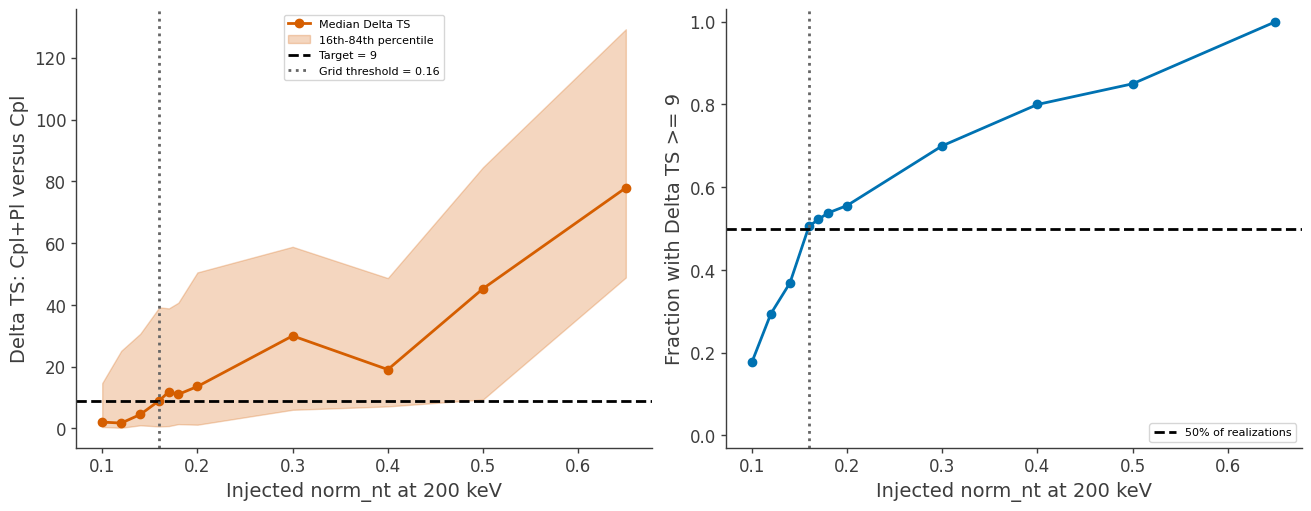

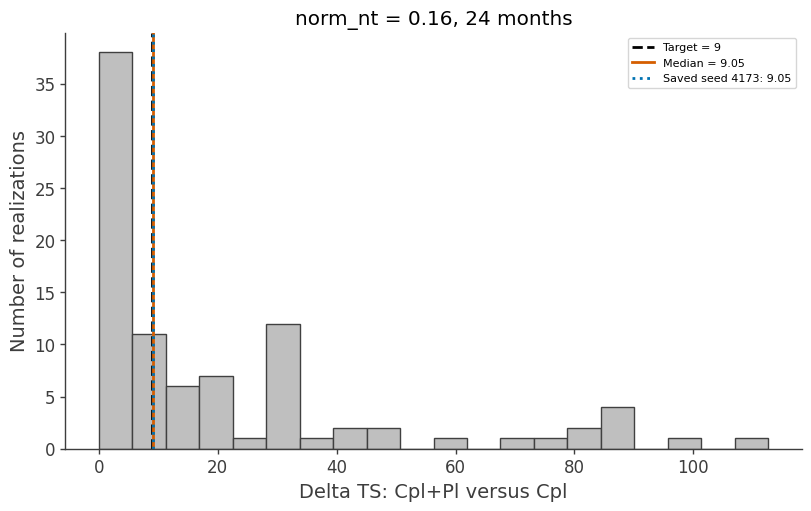

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

axes[0].plot(
    threshold_summary["norm_nt"],
    threshold_summary["median_delta_ts"],
    marker="o",
    color="#D55E00",
    label="Median Delta TS",
)
axes[0].fill_between(
    threshold_summary["norm_nt"],
    threshold_summary["delta_ts_q16"],
    threshold_summary["delta_ts_q84"],
    color="#D55E00",
    alpha=0.25,
    label="16th-84th percentile",
)
axes[0].axhline(target_delta_ts, color="black", linestyle="--", label=f"Target = {target_delta_ts:g}")
axes[0].axvline(selected_norm_nt, color="0.4", linestyle=":", label=f"Grid threshold = {selected_norm_nt:g}")
axes[0].set_xlabel("Injected norm_nt at 200 keV")
axes[0].set_ylabel("Delta TS: Cpl+Pl versus Cpl")
axes[0].legend()

axes[1].plot(
    threshold_summary["norm_nt"],
    threshold_summary["fraction_delta_ts_ge_target"],
    marker="o",
    color="#0072B2",
)
axes[1].axhline(0.5, color="black", linestyle="--", label="50% of realizations")
axes[1].axvline(selected_norm_nt, color="0.4", linestyle=":")
axes[1].set_ylim(-0.03, 1.03)
axes[1].set_xlabel("Injected norm_nt at 200 keV")
axes[1].set_ylabel(f"Fraction with Delta TS >= {target_delta_ts:g}")
axes[1].legend()

plt.show()

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.hist(selected_trials["delta_ts"], bins=20, color="0.75", edgecolor="0.25")
ax.axvline(target_delta_ts, color="black", linestyle="--", label=f"Target = {target_delta_ts:g}")
ax.axvline(
    selected_median_delta_ts,
    color="#D55E00",
    linestyle="-",
    label=f"Median = {selected_median_delta_ts:.2f}",
)
ax.axvline(
    representative_trial["delta_ts"],
    color="#0072B2",
    linestyle=":",
    label=f"Saved seed {representative_seed}: {representative_trial['delta_ts']:.2f}",
)
ax.set_xlabel("Delta TS: Cpl+Pl versus Cpl")
ax.set_ylabel("Number of realizations")
ax.set_title(f"norm_nt = {selected_norm_nt:g}, {exposure_months} months")
ax.legend()
plt.show()

## Handoff to the SED notebook

Load the manifest rather than hard-coding the seed-dependent filename. The SED notebook should use `median_data_file` as its data histogram, `source_expectation_file` for the injected curve/count checks, and the original three-month background multiplied by `background_exposure_multiplier`.

In [10]:
saved_manifest = json.loads(manifest_file.read_text())

sed_source_expectation = Histogram.open(saved_manifest["source_expectation_file"])
sed_data = Histogram.open(saved_manifest["median_data_file"])
sed_background = (
    Histogram.open(saved_manifest["background_file_3m"])
    .project("Em", "Phi", "PsiChi")
    * saved_manifest["background_exposure_multiplier"]
)
sed_norm_nt = saved_manifest["grid_threshold_norm_nt"]
sed_seed = saved_manifest["representative_seed"]

print(f"SED norm_nt: {sed_norm_nt}")
print(f"SED representative seed: {sed_seed}")
print(f"SED data file: {saved_manifest['median_data_file']}")

SED norm_nt: 0.16
SED representative seed: 4173
SED data file: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/GammaRay/Paper_Models/Fluctuate_True/Sensitivity_Ensemble/Case2_ec200/NGC4151_plus_bkg_ec_200_DC4_COSI_cpl_pl_60_fovCut_24months_threshold_normNT_0p16_medianSeed_4173.hdf5
